<a href="https://colab.research.google.com/github/CodeBlue0001/BCT-Training-Gen-AI/blob/main/BCT_GEN_AI_DAY_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rahuljaiswalonkaggle/soil-fertility-dataset")

print("Path to dataset files:", path)

100%|██████████| 16.9k/16.9k [00:00<00:00, 20.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/rahuljaiswalonkaggle/soil-fertility-dataset/versions/1


In [2]:
import pandas as pd
import matplotlib.pyplot as plt



In [3]:
df=pd.read_csv(r'/content/soil_fertility_dataset.csv')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/soil_fertility_dataset.csv'

In [ ]:
df2=pd.read_csv(r"/content/Soil-Climate-data.csv")
df2.head()

In [ ]:
df2.describe()

In [4]:
import sklearn
import numpy as np
import matplotlib.pyplot as plt


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

In [6]:
df=pd.read_csv(r'/content/Salary_Data.csv')
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [7]:
print(df.isnull().sum())

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64


In [9]:
df.dropna(inplace=True)
print(df.isnull().sum())

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


In [10]:
X=df['Salary']
X=np.array(X)
X=X.reshape(-1,1)
X

array([[ 90000.],
       [ 65000.],
       [150000.],
       ...,
       [ 55000.],
       [140000.],
       [ 35000.]])

In [11]:
Y=df['Years of Experience']
Y=np.array(Y)
Y=Y.reshape(-1,1)
Y

array([[ 5.],
       [ 3.],
       [15.],
       ...,
       [ 4.],
       [14.],
       [ 1.]])

In [12]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
# loading model
Regression_model=LinearRegression()
Regression_model

LinearRegression()

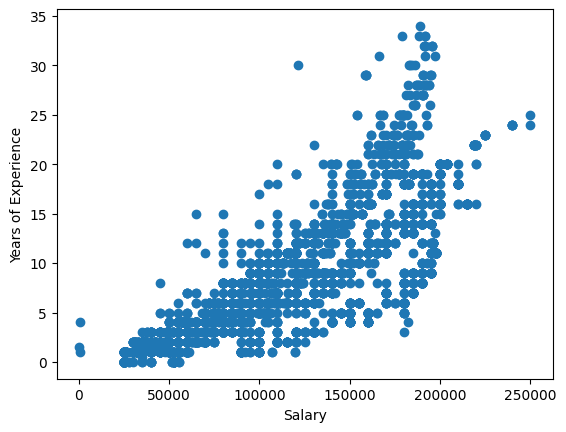

In [13]:
plt.scatter(x_train,y_train)
plt.xlabel('Salary')
plt.ylabel('Years of Experience')
plt.show()

In [14]:
# training model
Regression_model.fit(x_train,y_train)
r2_value=r2_score(y_test,Regression_model.predict(x_test))
r2_value


0.6556072496296397

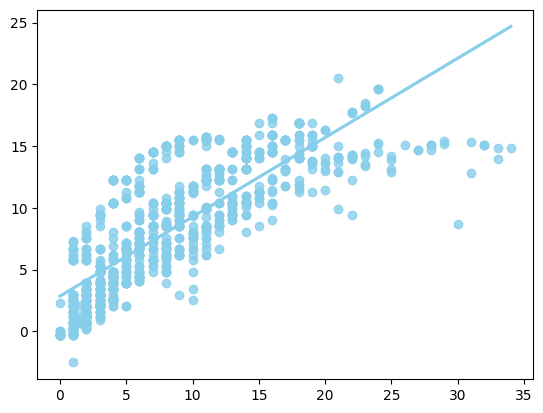

In [15]:
predicted_values=Regression_model.predict(x_test)
import seaborn as sns
sns.regplot(x=y_test,y=predicted_values,ci=None,color='skyblue')
plt.show()

/tmp/ipykernel_1315/2476311559.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test-predicted_values)


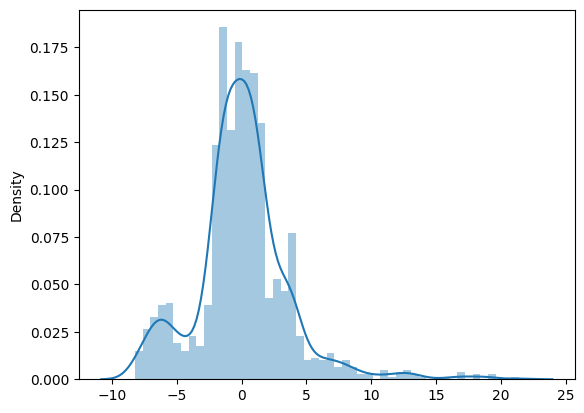

In [16]:
sns.distplot(y_test-predicted_values)
plt.show()

The accuracy of the singel valued linear regression ovbserved is not so good.

Lets clean the dataset
multi model according to their job description


In [17]:
data_analyst=df[df['Job Title']=='Data Analyst']
data_analyst.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
81,41.0,Female,Master's,Data Analyst,13.0,80000.0
378,27.0,Female,Bachelor's,Data Analyst,2.0,110000.0
382,25.0,Female,Master's,Data Analyst,1.0,100000.0
386,30.0,Female,Bachelor's,Data Analyst,5.0,145000.0


In [18]:
X_data_analyst=data_analyst['Salary']
X_data_analyst=np.array(X_data_analyst)
X_data_analyst=X_data_analyst.reshape(-1,1)

Y_data_analyst=data_analyst['Years of Experience']
Y_data_analyst=np.array(Y_data_analyst)
Y_data_analyst=Y_data_analyst.reshape(-1,1)

In [19]:
data_x_train,data_x_test,data_y_train,data_y_test=train_test_split(X_data_analyst,Y_data_analyst,test_size=0.33,random_state=3)
# loading model
data_analyst_model=LinearRegression()
data_analyst_model.fit(y_train,x_train)
data_analyst_model.score(y_test,x_test)

0.6555973709206209

# testing using polynomial regression model

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

In [21]:
# preprosesing the polinomial features
N=PolynomialFeatures(degree=2)
X_data_analyst_poly=N.fit_transform(x_train,y_train)
socre=LinearRegression()
socre.fit(X_data_analyst_poly,y_train)
socre.score(X_data_analyst_poly,y_train)

0.6583431762745566

### Multi-feature Linear Regression Model



In [22]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


X_multi = df[['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience']]
y_multi = df['Salary']

categorical_features = ['Gender', 'Education Level', 'Job Title']
numerical_features = ['Age', 'Years of Experience']


preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ])

# Create a pipeline with preprocessing and a linear regression model
multi_feature_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression()),

])

# Split the data into training and testing sets
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi, y_multi, test_size=0.33, random_state=3
)

# Train the model
multi_feature_model.fit(X_train_multi, y_train_multi)

# Evaluate the model
y_pred_multi = multi_feature_model.predict(X_test_multi)
r2_multi = r2_score(y_test_multi, y_pred_multi)
mae_multi = mean_absolute_error(y_test_multi, y_pred_multi)
mse_multi = mean_squared_error(y_test_multi, y_pred_multi)

print(f"R2 Score for Multi-feature Model: {r2_multi:.4f}")
print(f"Mean Absolute Error for Multi-feature Model: {mae_multi:.4f}")
print(f"Mean Squared Error for Multi-feature Model: {mse_multi:.4f}")

R2 Score for Multi-feature Model: 0.8811
Mean Absolute Error for Multi-feature Model: 13241.5059
Mean Squared Error for Multi-feature Model: 335166636.9765


/tmp/ipykernel_1315/1948768116.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test_multi-predicted)


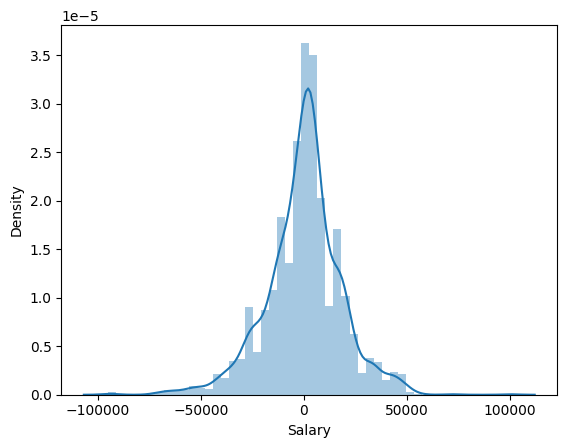

In [23]:
predicted=multi_feature_model.predict(X_test_multi)
import seaborn as sns
sns.distplot(y_test_multi-predicted)
plt.show()

In [26]:
# saving the model as pkl file
import joblib
model_name='multi_feature_model.pkl'
joblib.dump(multi_feature_model,model_name)


['multi_feature_model.pkl']